# Project Title - Vide Game Analysis

Type - EDA and Data Preparation

Team - Individual

Name - Rishi Raj

# Github Link

https://github.com/Rishiraj-coder/Video-Game-Analysis

# Problem Statement

The project aims to analyze and visualize video game sales and engagement data to
uncover trends in game popularity, user behavior, and platform performance. By
merging sales and engagement data, we seek to offer insights into how game features,
platforms, and genres influence sales, wishlists, and ratings. SQL will be used to
structure and store the data, while Power BI dashboards will be developed to guide
decision-making for game developers, marketers, and publishers.

# Know  your Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms

In [2]:
df = pd.read_csv('games.csv')
df1 = pd.read_csv('vgsales.csv')

In [3]:
# first view of the data sets
df.head()

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


In [4]:
df1.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
# last views
df.tail()

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
1507,1507,Back to the Future: The Game,"Dec 22, 2010",['Telltale Games'],3.2,94,94,"['Adventure', 'Point-and-Click']",Back to the Future: The Game is one of Telltal...,['Very enjoyable game. The story adds onto the...,763,5,223,67
1508,1508,Team Sonic Racing,"May 21, 2019","['Sumo Digital', 'Sega']",2.9,264,264,"['Arcade', 'Racing']",Team Sonic Racing combines the best elements o...,"['jogo morto mas bom', 'not my cup of tea', ""C...",1.5K,49,413,107
1509,1509,Dragon's Dogma,"May 22, 2012",['Capcom'],3.7,210,210,"['Brawler', 'RPG']","Set in a huge open world, Dragon’s Dogma: Dark...","['Underrated.', 'A grandes rasgos, es como un ...",1.1K,45,487,206
1510,1510,Baldur's Gate 3,"Oct 06, 2020",['Larian Studios'],4.1,165,165,"['Adventure', 'RPG', 'Strategy', 'Tactical', '...","An ancient evil has returned to Baldur's Gate,...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,269,79,388,602
1511,1511,The LEGO Movie Videogame,"Feb 04, 2014","['WB Games', 'TT Fusion']",2.8,184,184,"['Adventure', 'Puzzle']",Join Emmet and an unlikely group of resistance...,"['Legal', 'Pretty Average Lego Game But It Was...",1.7K,11,239,73


In [6]:
df1.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [7]:
# Dataset Rows & Columns count
df.shape

(1512, 14)

In [8]:
df1.shape

(16598, 11)

In [9]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [11]:
# Dataset Duplicate Value Count
# Check for duplicate values
duplicates = df.duplicated(keep=False)

# Count the duplicate values
duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    1512
Name: count, dtype: int64


In [12]:
duplicates = df1.duplicated(keep=False)

duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    16598
Name: count, dtype: int64


In [13]:
# Missing Values/Null Values Count
df.isnull().sum()

Unnamed: 0            0
Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [14]:
# Missing Values/Null Values Count
df1.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

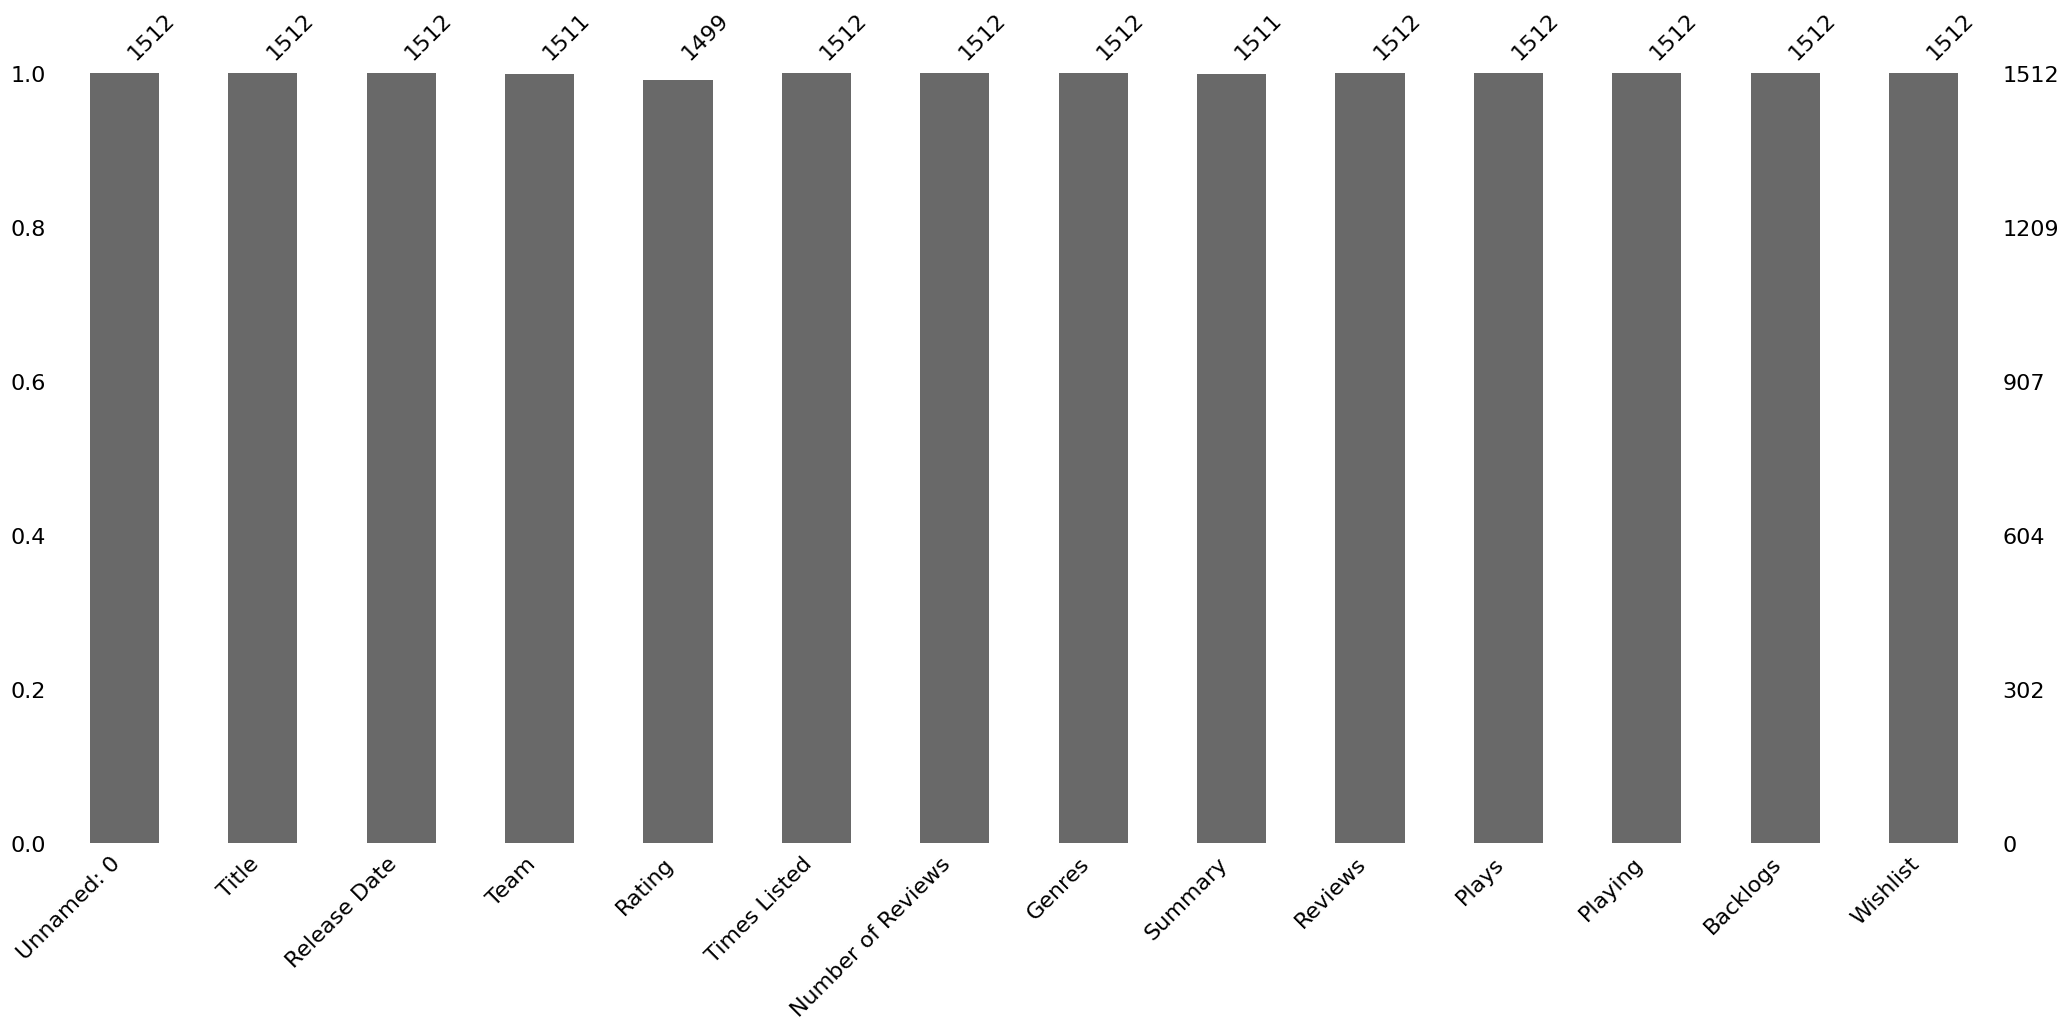

In [15]:
ms.bar(df)
plt.show()

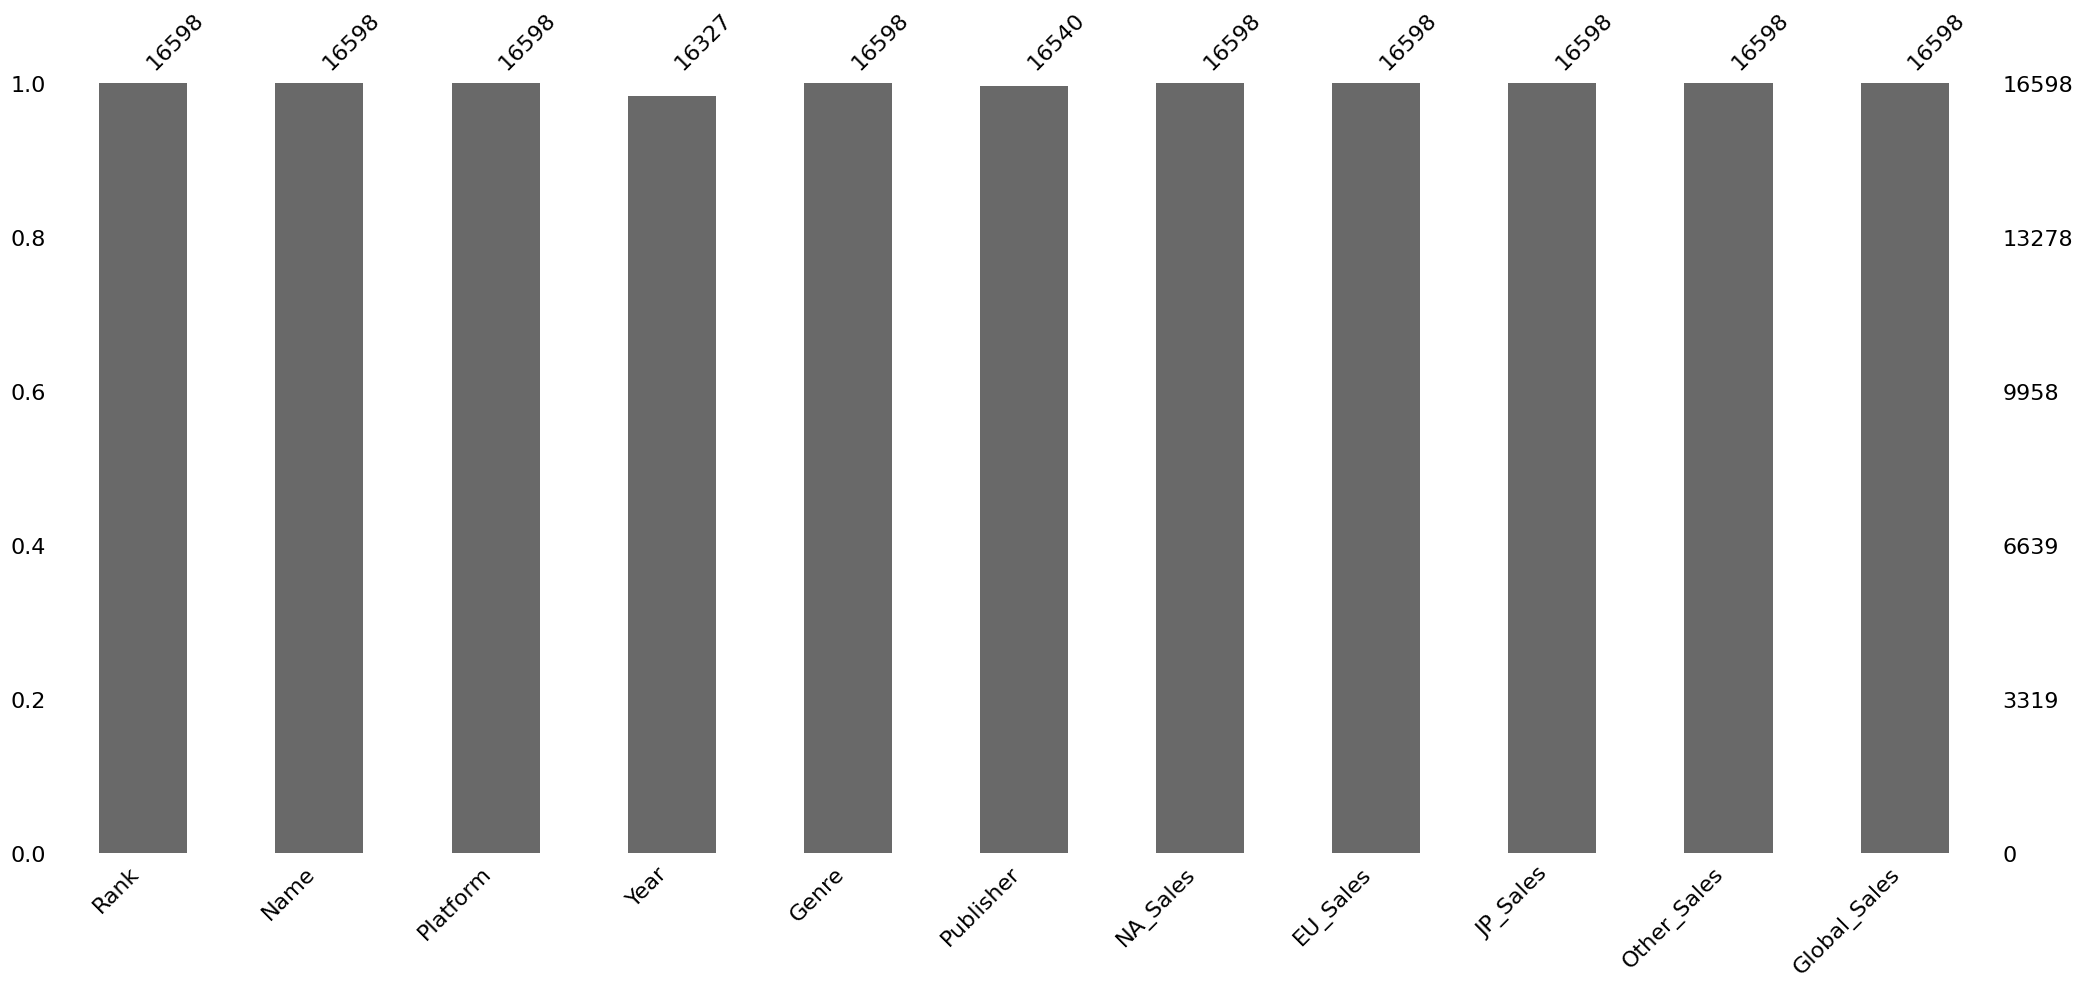

In [16]:
ms.bar(df1)
plt.show()

# What did you know about your dataset?

The dataset has two parts:-

The games dataset has 1512 rows and 14 rows and the vgsales dataset has 16598 rows and 11 columns

Missing values in datasets:

games dataset:

Team = 1

Rating = 13

Summary = 1

vgsales dataset:
 
years = 271

publisher = 58

# Understand Your Variables

In [17]:
# Dataset Columns
df.columns

Index(['Unnamed: 0', 'Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist'],
      dtype='object')

In [18]:
df1.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [19]:
# Dataset Describe
df.describe()

,Unnamed: 0,Rating
count,1512.000000,1499.000000
mean,755.500000,3.719346
std,436.621117,0.532608
min,0.000000,0.700000
25%,377.750000,3.400000
50%,755.500000,3.800000
75%,1133.250000,4.100000
max,1511.000000,4.800000


In [20]:
# Dataset Describe
df1.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


# Data Wrangling

In [21]:
df.isnull().sum()

Unnamed: 0            0
Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [22]:
df1.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

# Games Dataset

In [23]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [24]:
def convert_k(value):
    if isinstance(value, str):
        value = value.replace('K', '')
        return float(value) * 1000
    return value

cols_to_convert = ['Plays', 'Playing', 'Backlogs', 'Wishlist']

for col in cols_to_convert:
    df[col] = df[col].apply(convert_k)

In [25]:
# Convert ratings to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
# Convert year
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

In [26]:
df.drop_duplicates(inplace=True)

# VGsales Dataset

In [28]:
# Standardize column names
df1.columns = df1.columns.str.lower().str.strip()
# Handle missing Year
df1['year'] = df1['year'].fillna(df1['year'].median())

# Convert year to int
df1['year'] = df1['year'].astype(int)

# Remove duplicates
df1.drop_duplicates(inplace=True)

# Check again
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          16598 non-null  int64  
 1   name          16598 non-null  object 
 2   platform      16598 non-null  object 
 3   year          16598 non-null  int64  
 4   genre         16598 non-null  object 
 5   publisher     16540 non-null  object 
 6   na_sales      16598 non-null  float64
 7   eu_sales      16598 non-null  float64
 8   jp_sales      16598 non-null  float64
 9   other_sales   16598 non-null  float64
 10  global_sales  16598 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB
None


In [29]:
# Create total sales check column
df1['calculated_global'] = (
    df1['na_sales'] +
    df1['eu_sales'] +
    df1['jp_sales'] +
    df1['other_sales']
)

# Compare with global_sales
print((df1['global_sales'] - df1['calculated_global']).describe())

count    16598.000000
mean         0.000277
std          0.005223
min         -0.020000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.020000
dtype: float64


In [31]:
df.isnull().sum()

Title                 0
Release Date          3
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [33]:
# Convert to datetime
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

# Fill missing with median date
median_date = df['Release Date'].dropna().median()
df['Release Date'].fillna(median_date, inplace=True)

C:\Users\rishi\AppData\Local\Temp\ipykernel_28048\1945925647.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Release Date'].fillna(median_date, inplace=True)


In [34]:
df['Team'].fillna('Unknown', inplace=True)

C:\Users\rishi\AppData\Local\Temp\ipykernel_28048\3678582007.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Team'].fillna('Unknown', inplace=True)


In [35]:
df['Rating'] = df['Rating'].astype(float)

# Fill using genre-based average
df['Rating'] = df.groupby('Genres')['Rating'].transform(
    lambda x: x.fillna(x.mean())
)

In [37]:
df['Summary'].fillna('No description available', inplace=True)

C:\Users\rishi\AppData\Local\Temp\ipykernel_28048\646835091.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Summary'].fillna('No description available', inplace=True)


In [38]:
df.isnull().sum()

Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [39]:
df1.isnull().sum()

rank                  0
name                  0
platform              0
year                  0
genre                 0
publisher            58
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
global_sales          0
calculated_global     0
dtype: int64

In [40]:
df1['publisher'] = df1.groupby('genre')['publisher'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

In [41]:
df1.isnull().sum()

rank                 0
name                 0
platform             0
year                 0
genre                0
publisher            0
na_sales             0
eu_sales             0
jp_sales             0
other_sales          0
global_sales         0
calculated_global    0
dtype: int64

# Exploratory Data analysis

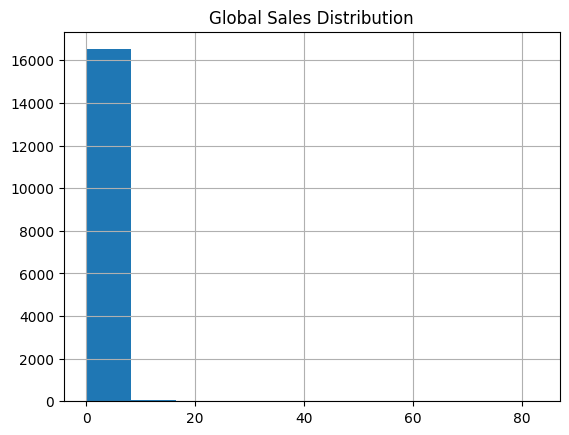

In [42]:
# Sales Distribution
df1['global_sales'].hist()
plt.title("Global Sales Distribution")
plt.show()

1.Why this chart?

Histogram shows distribution of a numerical variable
Helps identify skewness, spread, and outliers

2.Insights:

Data is right-skewed
Majority of games have low sales
Few games are blockbusters (very high sales)

3.Business Impact:

Gaming industry follows a hit-driven model
Companies should:

Invest more in high-quality flagship games,
Not rely on average-performing games,
Marketing budget should focus on potential hits.

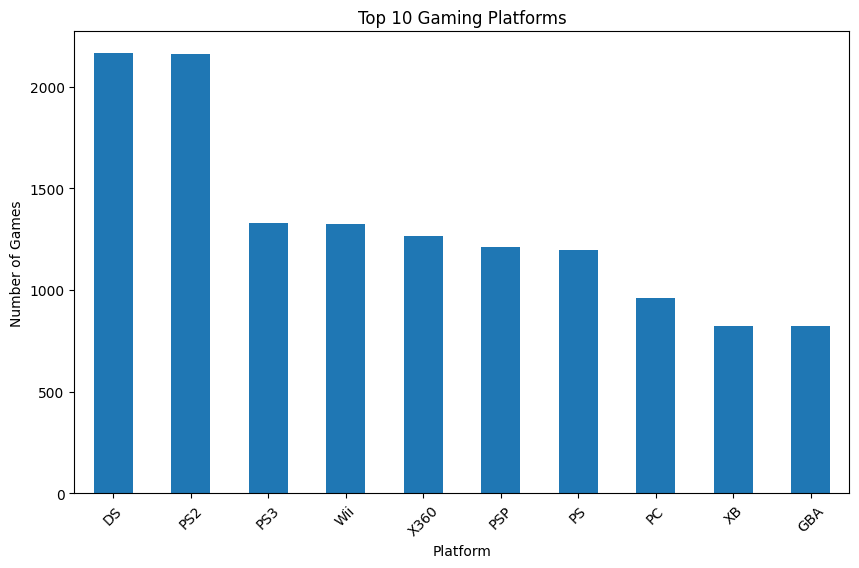

In [51]:
#Top Platforms
top_platforms = df1['platform'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_platforms.plot(kind='bar')

plt.title("Top 10 Gaming Platforms")
plt.xlabel("Platform")
plt.ylabel("Number of Games")

plt.xticks(rotation=45)
plt.show()

1.Why this chart?

Bar chart is best for comparing categories
Platforms are discrete categories

2.Insights:

Certain platforms dominate (e.g., PS, Xbox, Nintendo),
Some platforms have very low activity

3.Business Impact:

Focus game development on top-performing platforms,
Avoid investing heavily in declining platforms,
Helps in platform-specific marketing strategy.

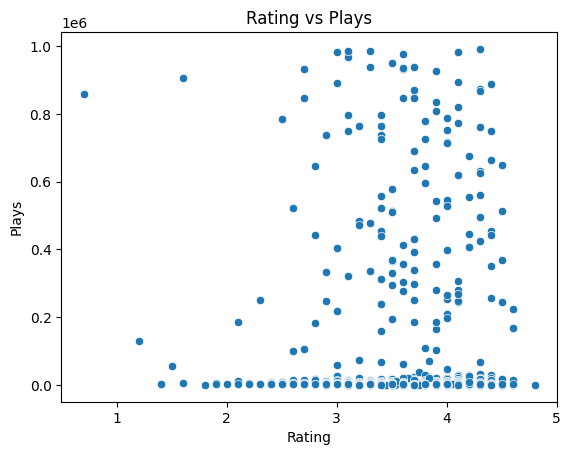

In [45]:
# Ratings vs Popularity
sns.scatterplot(x='Rating', y='Plays', data=df)
plt.title("Rating vs Plays")
plt.show()

1.Why this chart?

Scatter plot shows relationship between two variables
Helps detect correlation
 
2.Insights:

Weak or no strong correlation,
High-rated games don’t always have high plays,
Some low-rated games still have high engagement.

3.Business Impact:

Popularity ≠ Quality always & Marketing, hype, and brand matter

Companies should:

Invest in branding + promotion,
Not rely only on ratings

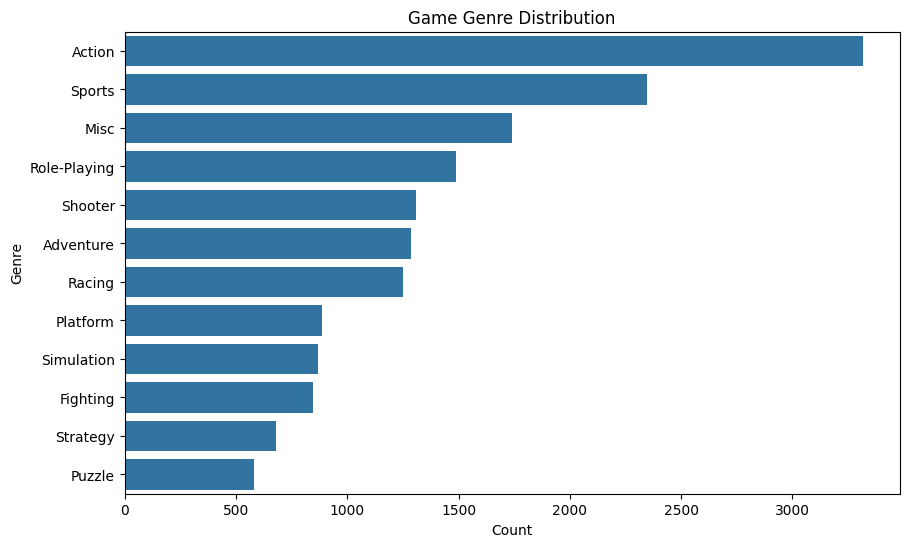

In [52]:
plt.figure(figsize=(10,6))
sns.countplot(y='genre', data=df1, order=df1['genre'].value_counts().index)

plt.title("Game Genre Distribution")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

1.Why this chart?

Count plot shows frequency of categories
Easy to identify most common genres

2.Insights:

Action, Sports, and Adventure dominate & 
Some genres are niche

3.Business Impact:

Focus on high-demand genres,
Opportunity in niche genres with less competition,
Helps in product portfolio planning.

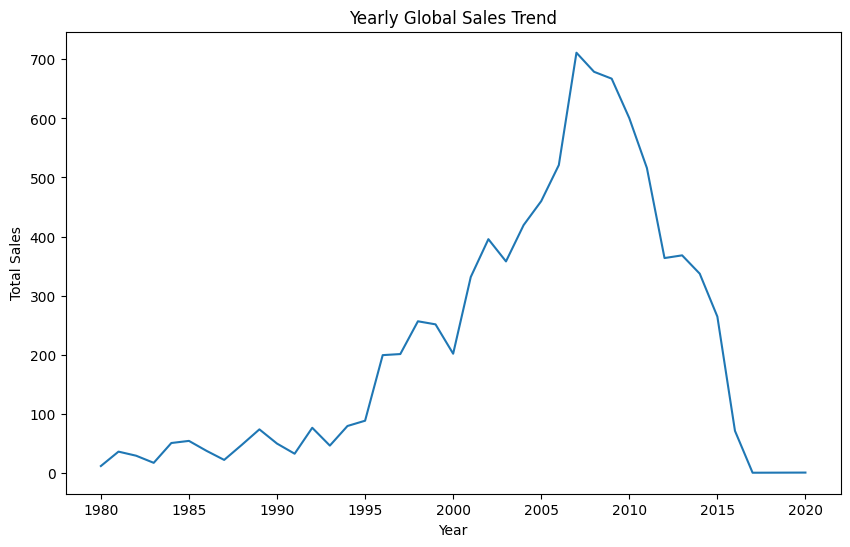

In [53]:
year_sales = df1.groupby('year')['global_sales'].sum()

plt.figure(figsize=(10,6))
year_sales.plot(kind='line')

plt.title("Yearly Global Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

1.Why this chart?

Line chart is best for time series data shows trends over time clearly.

2.Insights:

Growth phase → peak → decline/stability,
Industry cycles are visible

3.Business Impact:

Helps predict future demand,
Identifies golden periods for releases,
Useful for strategic planning.

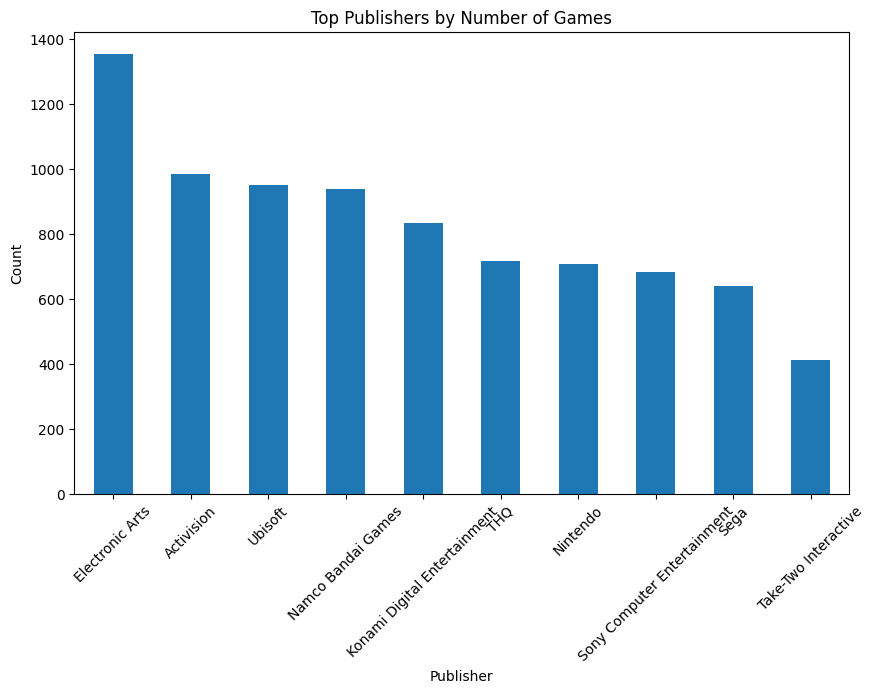

In [54]:
top_publishers = df1['publisher'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_publishers.plot(kind='bar')

plt.title("Top Publishers by Number of Games")
plt.xlabel("Publisher")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

1.Why this chart?

Bar chart helps compare publisher performance

2.Insights:
Few publishers dominate market
Long tail of smaller publishers

3.Business Impact:

Market is oligopolistic

Smaller companies should:
Focus on innovation or niche & 
Investors prefer top publishers

In [46]:
df['Title'] = df['Title'].str.lower().str.strip()
df1['name'] = df1['name'].str.lower().str.strip()

In [47]:
# merge datasets
merged = pd.merge(
    df,
    df1,
    left_on='Title',
    right_on='name',
    how='inner'
)

print(merged.head())

       Title Release Date                Team  Rating Times Listed  \
0  minecraft   2011-11-18  ['Mojang Studios']     4.3         2.3K   
1  minecraft   2011-11-18  ['Mojang Studios']     4.3         2.3K   
2  minecraft   2011-11-18  ['Mojang Studios']     4.3         2.3K   
3  minecraft   2011-11-18  ['Mojang Studios']     4.3         2.3K   
4  minecraft   2011-11-18  ['Mojang Studios']     4.3         2.3K   

  Number of Reviews                      Genres  \
0              2.3K  ['Adventure', 'Simulator']   
1              2.3K  ['Adventure', 'Simulator']   
2              2.3K  ['Adventure', 'Simulator']   
3              2.3K  ['Adventure', 'Simulator']   
4              2.3K  ['Adventure', 'Simulator']   

                                             Summary  \
0  Minecraft focuses on allowing the player to ex...   
1  Minecraft focuses on allowing the player to ex...   
2  Minecraft focuses on allowing the player to ex...   
3  Minecraft focuses on allowing the player to e

In [48]:
merged.columns

Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist', 'rank', 'name', 'platform', 'year', 'genre',
       'publisher', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales',
       'global_sales', 'calculated_global'],
      dtype='object')

# Exporting datasets for further analysis

In [50]:
df1.to_csv('clean_vgsales.csv', index=False)
df.to_csv('clean_games.csv', index=False)
merged.to_csv('final_dataset.csv', index=False)

# Summary 

1.Cleaned missing values and duplicates

2.Converted string-based metrics (K format) into numeric

3.Standardized column names

4.Performed data type corrections

5.Merged datasets for deeper insights